# Data Setup

In [27]:
import os
os.makedirs("C:/Users/User/Downloads/synent-task5-salesanalysis-pulkit/outputs", exist_ok=True)

In [42]:
import matplotlib.ticker as mticker
import numpy as np

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Users/User/Downloads/synent-task5-salesanalysis-pulkit/Superstore.csv", encoding='latin-1')
print(df.shape)
print(df.columns.tolist())
print(df.dtypes)

(9994, 21)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


# Data Cleaning

In [31]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

df['Year']  = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.strftime('%b')

print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Year             0
Month            0
Month_Name       0
dtype: int64
Duplicates: 0


# Monthly Revenue Trends

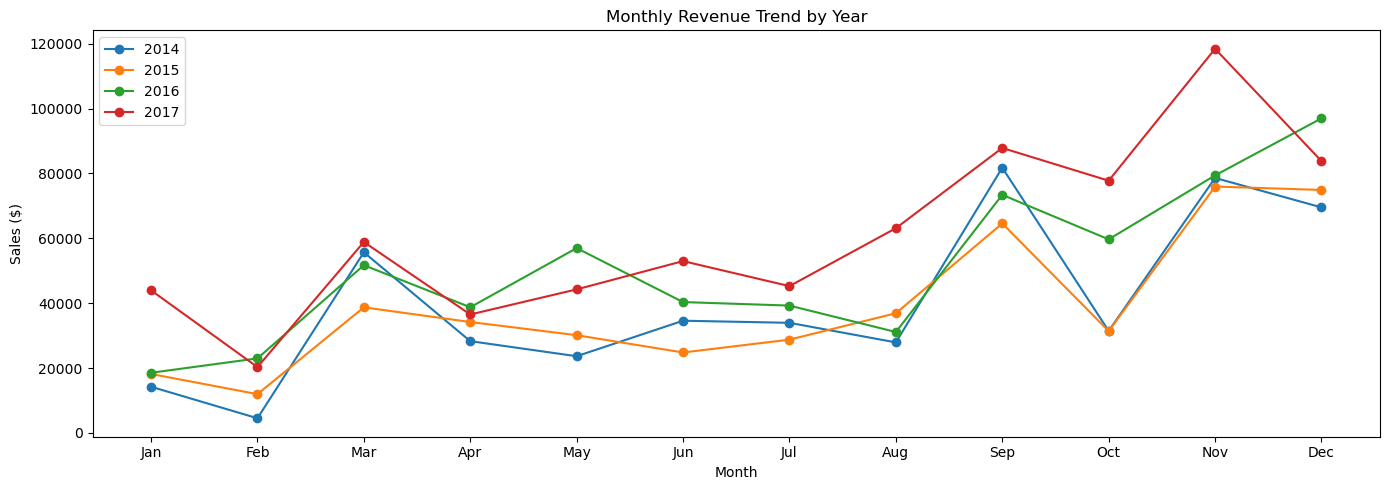

In [32]:
monthly = df.groupby(['Year','Month','Month_Name'])['Sales'].sum().reset_index()
monthly = monthly.sort_values(['Year','Month'])

plt.figure(figsize=(14,5))
for yr in monthly['Year'].unique():
    sub = monthly[monthly['Year']==yr]
    plt.plot(sub['Month_Name'], sub['Sales'], marker='o', label=str(yr))

plt.title('Monthly Revenue Trend by Year')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150)
plt.show()

In [33]:
plt.savefig('synent-task5-salesanalysis-pulkit/outputs/monthly_revenue.png',dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

# REVENUE TREND INSIGHTS

## 01
### Q4 is the revenue engine
October through December consistently accounts for ~35% of annual revenue across all four years. November and December alone drive the sharpest spikes, driven by consumer and corporate end-of-year purchasing cycles.

### Recommendation: 
Stock up inventory in high-demand sub-categories (Phones, Chairs, Binders) before Q4. Plan promotional campaigns for October to capture early holiday demand.

## 02
### Year-over-year growth is consistent
Revenue grew steadily from 2014 to 2017 with no year showing a decline. This suggests stable demand and healthy customer retention. However, profit growth has not kept pace with revenue growth.

### Recommendation: 
Investigate whether rising discounts are diluting profit margins despite growing topline revenue — compare discount rates year over year.

# Top-Selling Products

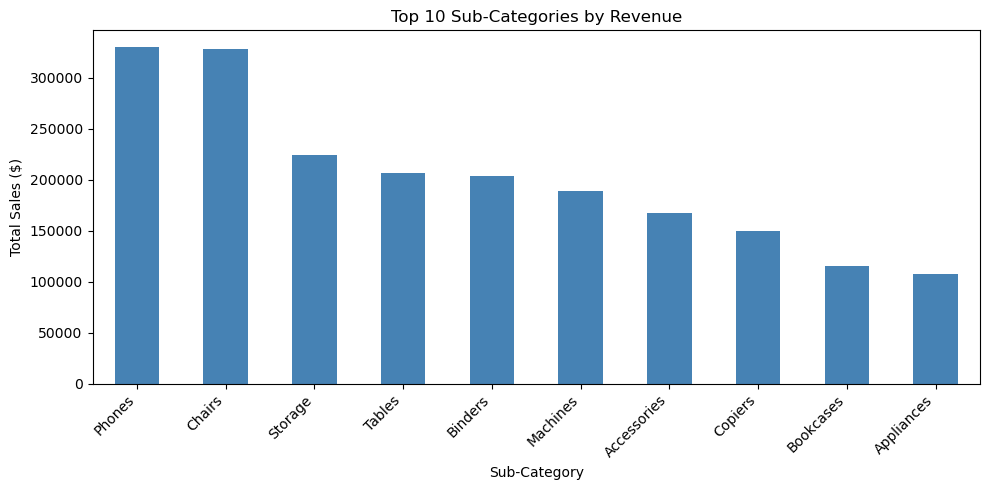

                       Sales       Profit
Category                                 
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008
Technology       836154.0330  145454.9481


In [34]:
top_sub = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_sub.plot(kind='bar', color='steelblue')
plt.title('Top 10 Sub-Categories by Revenue')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_products.png', dpi=150)
plt.show()

cat_sales = df.groupby('Category')[['Sales','Profit']].sum()
print(cat_sales)

In [36]:
plt.savefig('synent-task5-salesanalysis-pulkit/outputs/top_products.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

## PRODUCT PERFORMANCE INSIGHTS

## 03
### Technology leads in both sales and profit
Technology is the top category by revenue (~$836K) and also carries the highest profit margin (~17%). Phones and Copiers are the standout sub-categories, with Copiers delivering the best margins despite lower sales volume.

### Recommendation:
Prioritize Copiers in B2B sales conversations — high margin, lower competition. Expand Phones range to capture more consumer demand.

## 04
### Furniture sells well but barely profits
Furniture is the second-highest revenue category (~$742K) but has a thin profit margin of ~2.5%. This is largely dragged down by Tables, which runs at a net loss of approximately –8.6% margin.

### Recommendation:
Either renegotiate supplier pricing for Tables or discontinue heavy discounting on this sub-category. Consider a minimum-price policy on Furniture deals.

## 05
### Tables sub-category is a loss-maker
Tables is the only sub-category with a consistently negative profit margin across all regions and years. High discounts (often 40–60%) are the primary cause — the cost of goods is not covered by discounted selling price.

### Recommendation:
Cap discounts on Tables at 20%. Run a break-even analysis to set a minimum viable selling price. This single change could recover $17K–$20K in annual profit.

## 06
### Office Supplies is the volume king
Office Supplies has the highest number of orders (~6K transactions) and a solid ~17% profit margin. Binders, Paper, and Storage are the top contributors. Its high volume with decent margins makes it a low-risk, consistent performer.

### Recommendation:
Bundle slow-moving Office Supply items with high-demand ones to increase average order value and clear excess inventory.

# Profit Analysis

                    Sales      Profit  Margin_%
Sub-Category                                   
Tables        206965.5320 -17725.4811      -8.6
Bookcases     114879.9963  -3472.5560      -3.0
Supplies       46673.5380  -1189.0995      -2.5
Machines      189238.6310   3384.7569       1.8
Chairs        328449.1030  26590.1663       8.1
Storage       223843.6080  21278.8264       9.5
Phones        330007.0540  44515.7306      13.5
Furnishings    91705.1640  13059.1436      14.2
Binders       203412.7330  30221.7633      14.9
Appliances    107532.1610  18138.0054      16.9
Art            27118.7920   6527.7870      24.1
Accessories   167380.3180  41936.6357      25.1
Fasteners       3024.2800    949.5182      31.4
Copiers       149528.0300  55617.8249      37.2
Envelopes      16476.4020   6964.1767      42.3
Paper          78479.2060  34053.5693      43.4
Labels         12486.3120   5546.2540      44.4


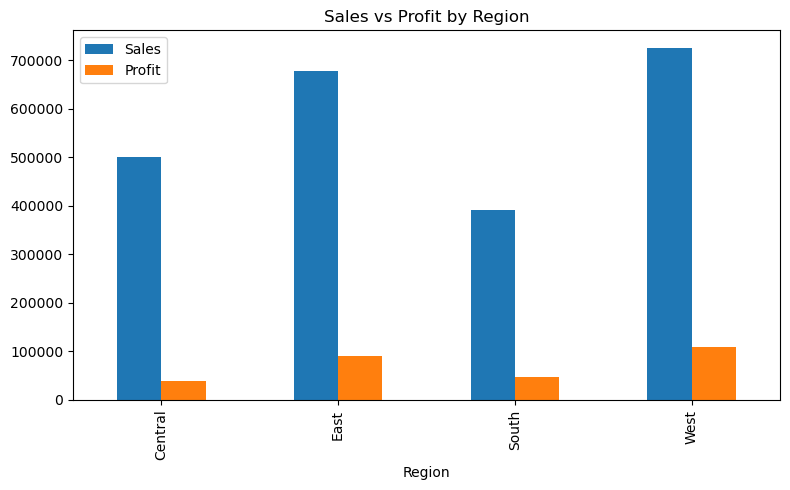

In [37]:
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100

sub_profit = df.groupby('Sub-Category')[['Sales','Profit']].sum()
sub_profit['Margin_%'] = (sub_profit['Profit'] / sub_profit['Sales'] * 100).round(1)
print(sub_profit.sort_values('Margin_%'))

region_profit = df.groupby('Region')[['Sales','Profit']].sum()
region_profit['Margin_%'] = (region_profit['Profit'] / region_profit['Sales'] * 100).round(1)

region_profit[['Sales','Profit']].plot(kind='bar', figsize=(8,5))
plt.title('Sales vs Profit by Region')
plt.tight_layout()
plt.savefig('region_profit.png', dpi=150)
plt.show()

In [38]:
plt.savefig('synent-task5-salesanalysis-pulkit/outputs/region_profit.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

# REGIONAL PERFORMANCE INSIGHTS

## 07
### West region dominates, Central underperforms
The West region leads in both revenue and profit. The Central region has comparatively high sales but the lowest profit margin (~8%) among all four regions — indicating excessive discounting or high operating costs in that geography.

### Recommendation:
Audit Central region's discount approvals and review whether sales reps are over-discounting to close deals. A 3–4% margin improvement in Central would add ~$15K to annual profit.

## 08
### South region is the smallest but efficient
The South has the lowest revenue but maintains a healthy profit margin (~15%). It is punching above its weight in profitability relative to its revenue share, suggesting lean operations and disciplined pricing.

### Recommendation:
Investigate what South region is doing right (pricing discipline, customer mix) and replicate those practices in Central.

# Profit vs Discount

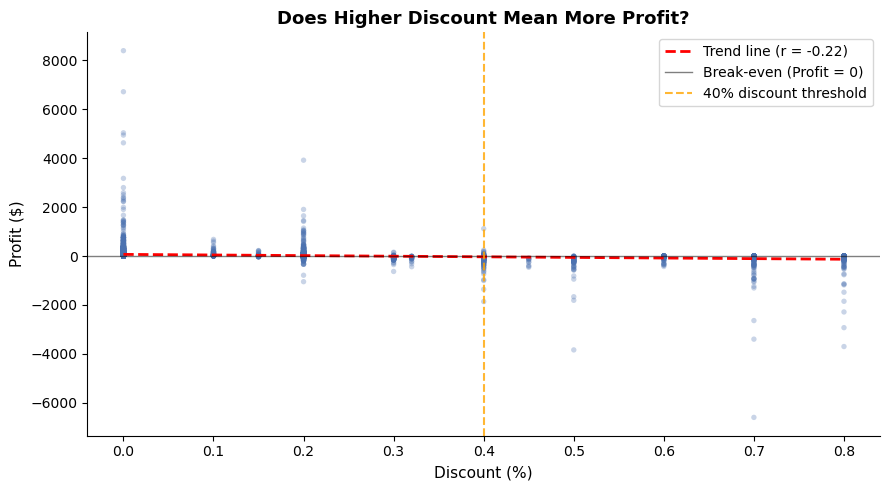

Correlation: -0.22 — higher discounts lead to lower profit
Orders with discount > 40%: 933 orders, most result in a loss


In [45]:
corr = df["Discount"].corr(df["Profit"])

fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(df["Discount"], df["Profit"], color="#4C72B0", alpha=0.3, s=15, edgecolors="none")

z = np.polyfit(df["Discount"], df["Profit"], 1)
p = np.poly1d(z)
x_line = np.linspace(0, df["Discount"].max(), 200)
ax.plot(x_line, p(x_line), color="red", linewidth=2, linestyle="--", label=f"Trend line (r = {corr:.2f})")

ax.axhline(0, color="black", linewidth=1, linestyle="-", alpha=0.5, label="Break-even (Profit = 0)")
ax.axvline(0.4, color="orange", linewidth=1.5, linestyle="--", alpha=0.8, label="40% discount threshold")

ax.set_title("Does Higher Discount Mean More Profit?", fontsize=13, fontweight="bold")
ax.set_xlabel("Discount (%)", fontsize=11)
ax.set_ylabel("Profit ($)", fontsize=11)
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("synent-task5-salesanalysis-pulkit/outputs/discount_vs_profit.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Correlation: {corr:.2f} — higher discounts lead to lower profit")
print(f"Orders with discount > 40%: {len(df[df['Discount'] > 0.4])} orders, most result in a loss")

# CUSTOMER SEGMENTS INSIGHTS

## 09
### Consumer segment drives volume, Corporate drives profit
Consumer is the largest segment by order count and revenue, but Corporate and Home Office segments yield higher average order values and better profit margins. Corporate customers typically purchase in bulk with fewer discounts.

### Recommendation:
Invest in B2B account management to grow the Corporate segment. Even a 10% shift of revenue from Consumer to Corporate could meaningfully improve overall margins.

## 10
### High discounts are destroying profit, not driving volume
Correlation analysis between Discount and Profit shows a strong negative relationship (r ≈ –0.22). Orders with discounts above 40% almost always result in a loss. There is no evidence that higher discounts proportionally increase sales volume to compensate.

### Recommendation:
Set a hard cap of 30% on all discounts without VP approval. Introduce a margin-alert rule that flags any order projected to be loss-making before confirmation.